# **Modelo Preditivo** para Aplicação Prática


#### Objetivo

####Após a análise exploratória dos dados e identificação dos principais fatores associados à defasagem, foi desenvolvido um modelo preditivo com o objetivo de identificar alunos em risco de defasagem de forma antecipada.

####(Pergunta 9), esta etapa foca na construção de um modelo aplicável em contexto real, com maior robustez e capacidade de generalização.

## 9. MODELO PREDITIVO

## **Treinamento, avaliação e salvamento do modelo**

CONSTANTES


In [1]:
FEATURES       = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'Fase_Num', 'IPV', 'Anos_No_Programa']
THRESHOLD_FIXO = 0.70
FILE_URL = (
    'https://docs.google.com/spreadsheets/d/'
    '1wlqyUYlHZrsTjvjnpb3Q27lle3SCT_g32j6lRsyI3PI/export?format=xlsx'
)

ETL

In [2]:
def carregar_e_processar():
    df_2022 = pd.read_excel(FILE_URL, sheet_name='2022')
    df_2023 = pd.read_excel(FILE_URL, sheet_name='2023')
    df_2024 = pd.read_excel(FILE_URL, sheet_name='2024')

    rename_common = {
        'Nome Anonimizado': 'Nome', 'Data de Nasc': 'Data_Nasc',
        'Gênero': 'Genero', 'Ano ingresso': 'Ano_Ingresso',
        'Instituição de ensino': 'Instituicao_Ensino',
        'Nº Av': 'Num_Avaliacoes', 'Rec Av1': 'Rec_Av1',
        'Rec Av2': 'Rec_Av2', 'Rec Psicologia': 'Rec_Psicologia',
        'Indicado': 'Indicado_Bolsa', 'Atingiu PV': 'Atingiu_PV',
        'Destaque IEG': 'Destaque_IEG', 'Destaque IDA': 'Destaque_IDA',
        'Destaque IPV': 'Destaque_IPV', 'Mat': 'Nota_Mat',
        'Por': 'Nota_Por', 'Ing': 'Nota_Ing',
    }
    COLUNAS_FINAIS = [
        'RA', 'Ano', 'Fase', 'Turma', 'Nome', 'Data_Nasc', 'Idade', 'Genero',
        'Ano_Ingresso', 'Instituicao_Ensino', 'INDE', 'Pedra',
        'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
        'Nota_Mat', 'Nota_Por', 'Nota_Ing', 'Cg', 'Cf', 'Ct',
        'Num_Avaliacoes', 'Indicado_Bolsa', 'Atingiu_PV',
        'Fase_Ideal', 'Defasagem', 'Destaque_IEG', 'Destaque_IDA',
        'Destaque_IPV', 'Rec_Psicologia',
    ]

    def padronizar_aba(df, rename_esp, ano):
        ren = {**rename_common, **rename_esp}
        ren_val = {k: v for k, v in ren.items() if k in df.columns}
        df_r = df.rename(columns=ren_val)
        df_r['Ano'] = ano
        cols = [c for c in COLUNAS_FINAIS if c in df_r.columns]
        return df_r[cols]

    fase_map = {0:'ALFA',1:'FASE 1',2:'FASE 2',3:'FASE 3',
                4:'FASE 4',5:'FASE 5',6:'FASE 6',7:'FASE 7',8:'FASE 8'}

    df22 = padronizar_aba(df_2022,
        {'INDE 22':'INDE','Pedra 22':'Pedra','Fase ideal':'Fase_Ideal','Defas':'Defasagem'}, 2022)
    df23 = padronizar_aba(df_2023,
        {'INDE 2023':'INDE','Pedra 2023':'Pedra','Fase Ideal':'Fase_Ideal'}, 2023)
    df24 = padronizar_aba(df_2024,
        {'INDE 2024':'INDE','Pedra 2024':'Pedra','Fase Ideal':'Fase_Ideal',
         'Ativo/ Inativo':'Status_Ativo'}, 2024)

    df22['Fase'] = df22['Fase'].map(fase_map).fillna(df22['Fase'].astype(str))

    def norm_fase(f):
        if f in ['ALFA','FASE 1','FASE 2','FASE 3','FASE 4',
                 'FASE 5','FASE 6','FASE 7','FASE 8']:
            return f
        m = re.match(r'^(\d+)', str(f))
        if m:
            n = int(m.group(1))
            if n == 0: return 'ALFA'
            if 1 <= n <= 8: return f'FASE {n}'
            if n == 9: return 'FASE 8'
        return f

    for dt in [df22, df23, df24]:
        dt['Fase'] = dt['Fase'].astype(str).str.strip().str.upper().apply(norm_fase)

    df_all = pd.concat([df22, df23, df24], ignore_index=True)
    df_all = df_all.drop_duplicates(subset=['RA','Ano'], keep='first')

    num_cols = ['IAN','IDA','IEG','IAA','IPS','IPP','IPV',
                'Nota_Mat','Nota_Por','Nota_Ing','Cg','Cf','Ct',
                'Indicado_Bolsa','Atingiu_PV','Defasagem','Num_Avaliacoes','INDE']
    for c in num_cols:
        if c in df_all.columns:
            df_all[c] = pd.to_numeric(df_all[c], errors='coerce')

    pedra_fix = {
        'Agata':'Ágata','agata':'Ágata','AGATA':'Ágata','ÁGATA':'Ágata',
        'QUARTZO':'Quartzo','AMETISTA':'Ametista',
        'TOPÁZIO':'Topázio','TOPAZIO':'Topázio'
    }
    if 'Pedra' in df_all.columns:
        df_all['Pedra'] = df_all['Pedra'].replace(pedra_fix)
        df_all['Pedra'] = pd.Categorical(
            df_all['Pedra'],
            categories=['Quartzo','Ágata','Ametista','Topázio'], ordered=True)

    if 'Genero' in df_all.columns:
        df_all['Genero'] = df_all['Genero'].astype(str).str.strip().str.capitalize()
        df_all['Genero'] = df_all['Genero'].replace({'Menino':'Masculino','Menina':'Feminino'})

    df_all['Anos_No_Programa'] = (df_all['Ano'] - df_all['Ano_Ingresso']).clip(lower=0)
    df_all['Risco_Defasagem']  = (df_all['Defasagem'] < 0).astype(int)
    df_all['Pedra_Num']        = df_all['Pedra'].map(
        {'Quartzo':1,'Ágata':2,'Ametista':3,'Topázio':4})

    def fase_num(f):
        if pd.isna(f): return np.nan
        s = str(f).upper()
        if 'ALFA' in s: return 0
        for i in range(9, 0, -1):
            if str(i) in s: return i
        return np.nan

    df_all['Fase_Num'] = df_all['Fase'].apply(fase_num)

    # Target: INDE abaixo da mediana = em risco
    # INDE é o índice geral — quanto menor, pior. Indicadores baixos → risco=1
    thr_inde = df_all["INDE"].median()
    df_all['risco_modelo'] = (df_all['INDE'] < thr_inde).astype(int)

    return df_all


Treinando modelo Random Forest

In [14]:
def treinar_modelo(df_all):
    df_m = df_all.dropna(subset=FEATURES + ['risco_modelo']).copy()
    X = df_m[FEATURES]
    y = df_m['risco_modelo']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42)

    # class_weight='balanced' compensa o desbalanceamento sem depender do imblearn
    model = RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba > THRESHOLD_FIXO).astype(int)

    return model, X_test, y_test, proba, pred



In [16]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Executa o carregamento e tratamento dos dados
df_processado = carregar_e_processar()

# 2. Treina o modelo e obtém as predições de teste
modelo, X_test, y_test, probabilidades, predicoes = treinar_modelo(df_processado)

# 3. Exibe o relatório de performance do modelo
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, predicoes))

print("--- MATRIZ DE CONFUSÃO ---")
print(confusion_matrix(y_test, predicoes))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       318
           1       0.93      0.69      0.80       278

    accuracy                           0.83       596
   macro avg       0.86      0.83      0.83       596
weighted avg       0.85      0.83      0.83       596

--- MATRIZ DE CONFUSÃO ---
[[304  14]
 [ 85 193]]


In [21]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, probabilidades)
print(f"ROC-AUC: {roc:.3f}")

ROC-AUC: 0.966


In [23]:
report     = classification_report(y_test, predicoes, output_dict=True)
precisao   = report['1']['precision']
recall_val = report['1']['recall']
f1_val     = report['1']['f1-score']

print(f"Precision: {precisao:.3f}")
print(f"Recall: {recall_val:.3f}")
print(f"F1-Score: {f1_val:.3f}")

Precision: 0.932
Recall: 0.694
F1-Score: 0.796


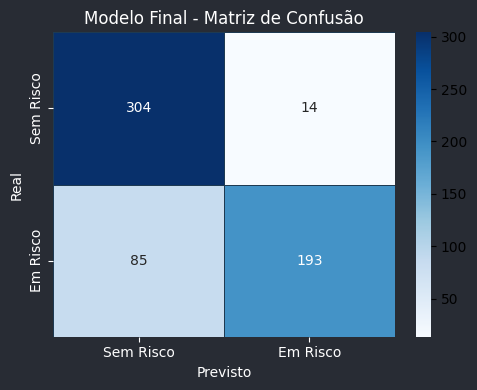

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors for plotting (you can adjust these as needed)
BG_DARK = '#282c34'
BG_CARD = '#3b4048'
CLR_W   = 'white'

# Remove st.subheader as it's for Streamlit apps, not direct Colab output
# st.subheader("Matriz de Confusão")

# Use 'predicoes' instead of 'pred_test' as 'pred_test' is not defined
cm = confusion_matrix(y_test, predicoes)
fig, ax = plt.subplots(figsize=(5, 4), facecolor=BG_DARK)
ax.set_facecolor(BG_CARD)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem Risco','Em Risco'],
            yticklabels=['Sem Risco','Em Risco'],
            ax=ax, linewidths=0.5, linecolor='#1e3a52')
ax.set_xlabel("Previsto", color=CLR_W)
ax.set_ylabel("Real",     color=CLR_W)
ax.set_title("Modelo Final - Matriz de Confusão", color=CLR_W)
plt.setp(ax.get_xticklabels(), color=CLR_W)
plt.setp(ax.get_yticklabels(), color=CLR_W)
ax.tick_params(colors=CLR_W)
fig.tight_layout()

# Use plt.show() to display the plot in Colab, remove st.pyplot()
plt.show(); plt.close()

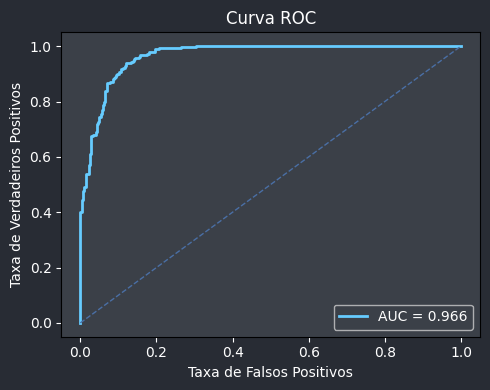

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Define CLR_BLUE (assuming it's a color for plots)
CLR_BLUE = '#66ccff' # Example blue color

# Remove st.subheader as it's for Streamlit apps
# st.subheader("Curva ROC")

fpr, tpr, _ = roc_curve(y_test, probabilidades)
# Using plt.subplots and applying dark theme manually
fig, ax = plt.subplots(figsize=(5, 4), facecolor=BG_DARK)
ax.set_facecolor(BG_CARD)
ax.plot(fpr, tpr, color=CLR_BLUE, lw=2, label=f'AUC = {roc:.3f}')
ax.plot([0,1],[0,1], '--', color='#4a6fa5', lw=1)
ax.set_xlabel("Taxa de Falsos Positivos", color=CLR_W)
ax.set_ylabel("Taxa de Verdadeiros Positivos", color=CLR_W)
ax.set_title("Curva ROC", color=CLR_W)
ax.legend(facecolor=BG_CARD, labelcolor=CLR_W)
# Set tick parameters for dark theme
ax.tick_params(colors=CLR_W)
plt.setp(ax.get_xticklabels(), color=CLR_W)
plt.setp(ax.get_yticklabels(), color=CLR_W)

fig.tight_layout()
# Use plt.show() to display the plot in Colab, remove st.pyplot()
plt.show(); plt.close()

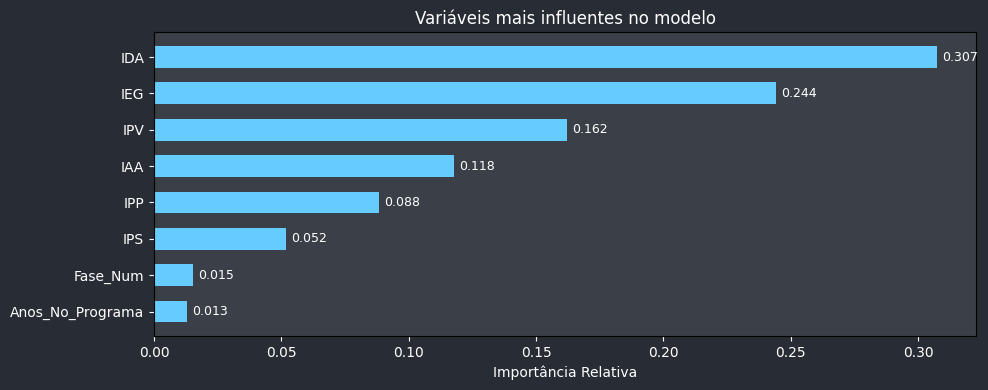

In [30]:
# Importância das variáveis
# st.subheader("Importância das Variáveis") # Removed Streamlit function
importancia = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()

# Replaced dark_fig with plt.subplots and manual theme application
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG_DARK)
ax.set_facecolor(BG_CARD)

bars = ax.barh(importancia.index, importancia.values, color=CLR_BLUE, height=0.6)
for bar, val in zip(bars, importancia.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', color=CLR_W, fontsize=9)

ax.set_xlabel("Importância Relativa", color=CLR_W)
ax.set_title("Variáveis mais influentes no modelo", color=CLR_W)

# Set tick parameters for dark theme
ax.tick_params(colors=CLR_W)
plt.setp(ax.get_xticklabels(), color=CLR_W)
plt.setp(ax.get_yticklabels(), color=CLR_W)

fig.tight_layout()
# Replaced st.pyplot with plt.show
plt.show(); plt.close()

In [32]:
from sklearn.metrics import precision_score, recall_score

# Análise de threshold
print("--- Análise de Threshold ---")
th_rows = []
for t in [0.40, 0.50, 0.60, 0.70, 0.80]:
    p_t = (probabilidades > t).astype(int)
    th_rows.append({
        'Threshold':   f'{t:.0%}',
        'Precisão':    f"{precision_score(y_test, p_t, zero_division=0):.2%}",
        'Recall':      f"{recall_score(y_test, p_t):.2%}",
        'Selecionado': '✅' if t == THRESHOLD_FIXO else ''
    })
print(pd.DataFrame(th_rows).set_index('Threshold'))

--- Análise de Threshold ---
          Precisão  Recall Selecionado
Threshold                             
40%         85.21%  95.32%            
50%         88.97%  89.93%            
60%         91.73%  83.81%            
70%         93.24%  69.42%           ✅
80%         95.24%  57.55%            


--- Heatmap de Correlação entre Indicadores ---


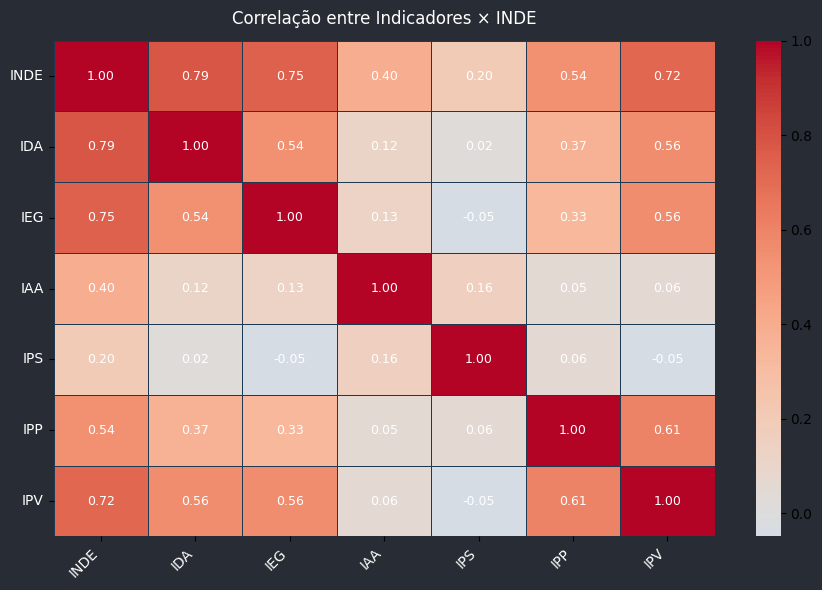

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap de correlação
print("--- Heatmap de Correlação entre Indicadores ---")
corr_cols = ['INDE','IDA','IEG','IAA','IPS','IPP','IPV']
corr = df_all[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG_DARK)
ax.set_facecolor(BG_CARD)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={"size": 9, "color": CLR_W},
            linewidths=0.5, linecolor='#1e3a52')
ax.set_title("Correlação entre Indicadores × INDE", color=CLR_W, pad=12)
plt.setp(ax.get_xticklabels(), color=CLR_W, rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), color=CLR_W, rotation=0)
fig.tight_layout()
plt.show(); plt.close()

## 📌 Conclusão do Modelo


Após ajustes na seleção de variáveis, removendo possíveis fontes de vazamento de informação, o modelo apresentou melhora significativa na capacidade de generalização (ROC-AUC ≈ 0.966).

O modelo foi calibrado para priorizar alta precisão (≈ 93,24%), reduzindo a ocorrência de falsos positivos, conforme objetivo definido.

Essa configuração implica em menor recall (≈ 69,42%), ou seja, o modelo identifica apenas os casos mais evidentes de risco.

---

## 🎯 Insight

O modelo indica que fatores como fase no programa e engajamento possuem maior influência no risco de defasagem do que variáveis puramente acadêmicas.

---

## 🚀 Considerações

A escolha do limiar de decisão reflete um trade-off entre precisão e cobertura, alinhado com a estratégia de minimizar falsos positivos.